In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
# getting the values from the dataeset
df = pd.read_csv("/content/drive/MyDrive/SDGP/ML/Dataset - Long beans.csv", encoding="utf-8")

In [62]:
# printing the first 5 values
df.head()

,Year,Month,Producer Price Rs/kg,Wholesale Price Rs/kg,Retail Price Rs/kg,Month on CCIP change,Month on CCIP (Core) change,Inflation rate CCIP on Food monthly (Base Value 17044.70),Inflation rate CCIP on Non-Food monthly (Base Value 43320.04),Inflation rate NCIP on Food monthly (Base Value 14156.29),...,Maximum Temperature,Colombo Rainfall mm,Galle Rainfall mm,Hambantota Rainfall mm,Colombo Production MT,Gampaha Production MT,Kaluthara Production MT,Galle Production MT,Hambantota Production MT,Matara Production MT
0,2014,January,22.37,29.99,93.59,0%,0%,0.4%,5.7%,0.3%,...,31.4,85.6,61.0,2.4,0.0,46.2,62.7,86.3,1365.7,27.8
1,2014,February,28.77,30.29,91.75,0%,0%,-0.2%,0.1%,-0.5%,...,31.6,19.5,42.9,0.0,0.0,46.2,62.7,86.3,1365.7,27.8
2,2014,March,29.89,27.78,88.47,0%,0.3%,-0.3%,0.1%,0.3%,...,32.3,144.8,68.0,97.6,0.0,46.2,62.7,86.3,1365.7,27.8
3,2014,April,33.26,36.83,85.06,0.2%,0.1%,0.8%,0%,1.7%,...,32.2,254.7,158.7,13.6,12.8,23.5,32.0,67.2,158.0,133.3
4,2014,May,48.12,62.59,119.51,0.4%,0%,1.5%,-0.1%,1.9%,...,31.6,83.5,185.1,76.1,12.8,23.5,32.0,67.2,158.0,133.3


Renaming the columns to a more efficent progression.

In [63]:
# renaming columns for easy progression
df.rename(columns={
    'Year': 'year',
    'Month': 'month',
    'Producer Price Rs/kg': 'producer_price',
    'Wholesale Price Rs/kg': 'wholesale_price',
    'Retail Price Rs/kg': 'retail_price',
    'Month on CCIP change': 'month_ccip_change',
    'Month on CCIP (Core) change': 'month_ccip_core_change',
    'Inflation rate CCIP on Food monthly (Base Value 17044.70)': 'inflation_ccip_food',
    'Inflation rate CCIP on Non-Food monthly (Base Value 43320.04)': 'inflation_ccip_non_food',
    'Inflation rate NCIP on Food monthly (Base Value 14156.29)': 'inflation_ncip_food',
    'Inflation rate NCIP on Non-Food monthly (Base Value 17986.41)': 'inflation_ncip_non_food',
    'Inflation rate NCIP on All Items monthly (Base Value32142.69)': 'inflation_ncip_all_items',
    'Minimum Temperature': 'min_temperature',
    'Maximum Temperature': 'max_temperature',
    'Colombo Rainfall mm': 'colombo_rainfall_mm',
    'Galle Rainfall mm': 'galle_rainfall_mm',
    'Hambantota Rainfall mm': 'hambantota_rainfall_mm',
    'Colombo Production MT' : 'colombo_production_mt',
    'Gampaha Production MT' : 'gampaha_production_mt',
    'Kaluthara Production MT' : 'kaluthara_production_mt',
    'Galle Production MT' : 'galle_production_mt',
    'Hambantota Production MT' : 'hambantota_production_mt',
    'Matara Production MT' : 'matara_production_mt'
}, inplace=True)
df.head()

,year,month,producer_price,wholesale_price,retail_price,month_ccip_change,month_ccip_core_change,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,...,max_temperature,colombo_rainfall_mm,galle_rainfall_mm,hambantota_rainfall_mm,colombo_production_mt,gampaha_production_mt,kaluthara_production_mt,galle_production_mt,hambantota_production_mt,matara_production_mt
0,2014,January,22.37,29.99,93.59,0%,0%,0.4%,5.7%,0.3%,...,31.4,85.6,61.0,2.4,0.0,46.2,62.7,86.3,1365.7,27.8
1,2014,February,28.77,30.29,91.75,0%,0%,-0.2%,0.1%,-0.5%,...,31.6,19.5,42.9,0.0,0.0,46.2,62.7,86.3,1365.7,27.8
2,2014,March,29.89,27.78,88.47,0%,0.3%,-0.3%,0.1%,0.3%,...,32.3,144.8,68.0,97.6,0.0,46.2,62.7,86.3,1365.7,27.8
3,2014,April,33.26,36.83,85.06,0.2%,0.1%,0.8%,0%,1.7%,...,32.2,254.7,158.7,13.6,12.8,23.5,32.0,67.2,158.0,133.3
4,2014,May,48.12,62.59,119.51,0.4%,0%,1.5%,-0.1%,1.9%,...,31.6,83.5,185.1,76.1,12.8,23.5,32.0,67.2,158.0,133.3


In [64]:
missing_values = df.isnull().sum()
print('Missing values')
print(missing_values)

Missing values
year                         0
month                        0
producer_price               1
wholesale_price              4
retail_price                 0
month_ccip_change            0
month_ccip_core_change       0
inflation_ccip_food          0
inflation_ccip_non_food      0
inflation_ncip_food          0
inflation_ncip_non_food      0
inflation_ncip_all_items     0
min_temperature             48
max_temperature             48
colombo_rainfall_mm          0
galle_rainfall_mm            0
hambantota_rainfall_mm       0
colombo_production_mt        0
gampaha_production_mt        0
kaluthara_production_mt      0
galle_production_mt          0
hambantota_production_mt     0
matara_production_mt         0
dtype: int64


The temperature columns were dropped due to the lare amount of missing data.

In [65]:
# dropping the temperature columns as there are several missing values for these columns
df = df.drop(['min_temperature', 'max_temperature'], axis=1)
df.head()

,year,month,producer_price,wholesale_price,retail_price,month_ccip_change,month_ccip_core_change,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,...,inflation_ncip_all_items,colombo_rainfall_mm,galle_rainfall_mm,hambantota_rainfall_mm,colombo_production_mt,gampaha_production_mt,kaluthara_production_mt,galle_production_mt,hambantota_production_mt,matara_production_mt
0,2014,January,22.37,29.99,93.59,0%,0%,0.4%,5.7%,0.3%,...,3.1%,85.6,61.0,2.4,0.0,46.2,62.7,86.3,1365.7,27.8
1,2014,February,28.77,30.29,91.75,0%,0%,-0.2%,0.1%,-0.5%,...,-0.1%,19.5,42.9,0.0,0.0,46.2,62.7,86.3,1365.7,27.8
2,2014,March,29.89,27.78,88.47,0%,0.3%,-0.3%,0.1%,0.3%,...,0.2%,144.8,68.0,97.6,0.0,46.2,62.7,86.3,1365.7,27.8
3,2014,April,33.26,36.83,85.06,0.2%,0.1%,0.8%,0%,1.7%,...,0.9%,254.7,158.7,13.6,12.8,23.5,32.0,67.2,158.0,133.3
4,2014,May,48.12,62.59,119.51,0.4%,0%,1.5%,-0.1%,1.9%,...,0.8%,83.5,185.1,76.1,12.8,23.5,32.0,67.2,158.0,133.3


function for efficent caluculation of the mean values for prices based on the month.

In [66]:
def filling_missing_prices_with_mean(month, price):
  # selecting the rows of the april month
  filtered_df = df[df["month"] == month]

  # caluclating the mean of the producer price column
  price_mean = filtered_df[price].mean()
  print(price_mean)

  # replacing NaN values with the mean
  df.loc[df["month"] == month, price] = df.loc[df["month"] == month, price].fillna(price_mean)

  print(f"{price} of {month} filled with the mean")


In [67]:
filling_missing_prices_with_mean("April", "producer_price")

51.26875
producer_price of April filled with the mean


In [68]:
missing_values = df.isnull().sum()
print('Missing values')
print(missing_values)

Missing values
year                        0
month                       0
producer_price              0
wholesale_price             4
retail_price                0
month_ccip_change           0
month_ccip_core_change      0
inflation_ccip_food         0
inflation_ccip_non_food     0
inflation_ncip_food         0
inflation_ncip_non_food     0
inflation_ncip_all_items    0
colombo_rainfall_mm         0
galle_rainfall_mm           0
hambantota_rainfall_mm      0
colombo_production_mt       0
gampaha_production_mt       0
kaluthara_production_mt     0
galle_production_mt         0
hambantota_production_mt    0
matara_production_mt        0
dtype: int64


In [69]:
filling_missing_prices_with_mean("April", "wholesale_price")
filling_missing_prices_with_mean("October", "wholesale_price")
filling_missing_prices_with_mean("November", "wholesale_price")
filling_missing_prices_with_mean("December", "wholesale_price")

54.7225
wholesale_price of April filled with the mean
100.57000000000001
wholesale_price of October filled with the mean
134.59375
wholesale_price of November filled with the mean
145.66625
wholesale_price of December filled with the mean


All missing values have been flled or removed

In [70]:
missing_values = df.isnull().sum()
print('Missing values')
print(missing_values)

Missing values
year                        0
month                       0
producer_price              0
wholesale_price             0
retail_price                0
month_ccip_change           0
month_ccip_core_change      0
inflation_ccip_food         0
inflation_ccip_non_food     0
inflation_ncip_food         0
inflation_ncip_non_food     0
inflation_ncip_all_items    0
colombo_rainfall_mm         0
galle_rainfall_mm           0
hambantota_rainfall_mm      0
colombo_production_mt       0
gampaha_production_mt       0
kaluthara_production_mt     0
galle_production_mt         0
hambantota_production_mt    0
matara_production_mt        0
dtype: int64


Function to calculate a integer value using a starting base value and the the column for the operiton to be processed to.

In [71]:
# function for automatic calculation of usning te base value and the percentage in the columns
def calc_values_using_percentage(base_val, column_name):
  base_value = base_val
  calculated_values = [base_value]  # Start with the base value for January

  # Process the month_ccip_change to calculate the new values
  for i in range(1, len(df)):
      # Convert percentage change to numeric (e.g., "0.4%" → 0.004)
      percentage_change = float(df.loc[i, column_name].strip('%')) / 100
      # Calculate the new value based on the previous month's value
      new_value = calculated_values[-1] * (1 + percentage_change)
      calculated_values.append(new_value)

  # Update the DataFrame
  df[column_name] = calculated_values

Converted the ccpi values

In [72]:
# updating the ccip values
calc_values_using_percentage(17116.88, "inflation_ccip_food")
calc_values_using_percentage(45789.28, "inflation_ccip_non_food")

df.head()

,year,month,producer_price,wholesale_price,retail_price,month_ccip_change,month_ccip_core_change,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,...,inflation_ncip_all_items,colombo_rainfall_mm,galle_rainfall_mm,hambantota_rainfall_mm,colombo_production_mt,gampaha_production_mt,kaluthara_production_mt,galle_production_mt,hambantota_production_mt,matara_production_mt
0,2014,January,22.37,29.99,93.59,0%,0%,17116.880000,45789.280000,0.3%,...,3.1%,85.6,61.0,2.4,0.0,46.2,62.7,86.3,1365.7,27.8
1,2014,February,28.77,30.29,91.75,0%,0%,17082.646240,45835.069280,-0.5%,...,-0.1%,19.5,42.9,0.0,0.0,46.2,62.7,86.3,1365.7,27.8
2,2014,March,29.89,27.78,88.47,0%,0.3%,17031.398301,45880.904349,0.3%,...,0.2%,144.8,68.0,97.6,0.0,46.2,62.7,86.3,1365.7,27.8
3,2014,April,33.26,36.83,85.06,0.2%,0.1%,17167.649488,45880.904349,1.7%,...,0.9%,254.7,158.7,13.6,12.8,23.5,32.0,67.2,158.0,133.3
4,2014,May,48.12,62.59,119.51,0.4%,0%,17425.164230,45835.023445,1.9%,...,0.8%,83.5,185.1,76.1,12.8,23.5,32.0,67.2,158.0,133.3


Filled the ncpi

In [73]:
# updating the ncip values
calc_values_using_percentage(14198.75, "inflation_ncip_food")
calc_values_using_percentage(18921.70, "inflation_ncip_non_food")
calc_values_using_percentage(33139.11, "inflation_ncip_all_items")

df.head()

,year,month,producer_price,wholesale_price,retail_price,month_ccip_change,month_ccip_core_change,inflation_ccip_food,inflation_ccip_non_food,inflation_ncip_food,...,inflation_ncip_all_items,colombo_rainfall_mm,galle_rainfall_mm,hambantota_rainfall_mm,colombo_production_mt,gampaha_production_mt,kaluthara_production_mt,galle_production_mt,hambantota_production_mt,matara_production_mt
0,2014,January,22.37,29.99,93.59,0%,0%,17116.880000,45789.280000,14198.750000,...,33139.110000,85.6,61.0,2.4,0.0,46.2,62.7,86.3,1365.7,27.8
1,2014,February,28.77,30.29,91.75,0%,0%,17082.646240,45835.069280,14127.756250,...,33105.970890,19.5,42.9,0.0,0.0,46.2,62.7,86.3,1365.7,27.8
2,2014,March,29.89,27.78,88.47,0%,0.3%,17031.398301,45880.904349,14170.139519,...,33172.182832,144.8,68.0,97.6,0.0,46.2,62.7,86.3,1365.7,27.8
3,2014,April,33.26,36.83,85.06,0.2%,0.1%,17167.649488,45880.904349,14411.031891,...,33470.732477,254.7,158.7,13.6,12.8,23.5,32.0,67.2,158.0,133.3
4,2014,May,48.12,62.59,119.51,0.4%,0%,17425.164230,45835.023445,14684.841496,...,33738.498337,83.5,185.1,76.1,12.8,23.5,32.0,67.2,158.0,133.3


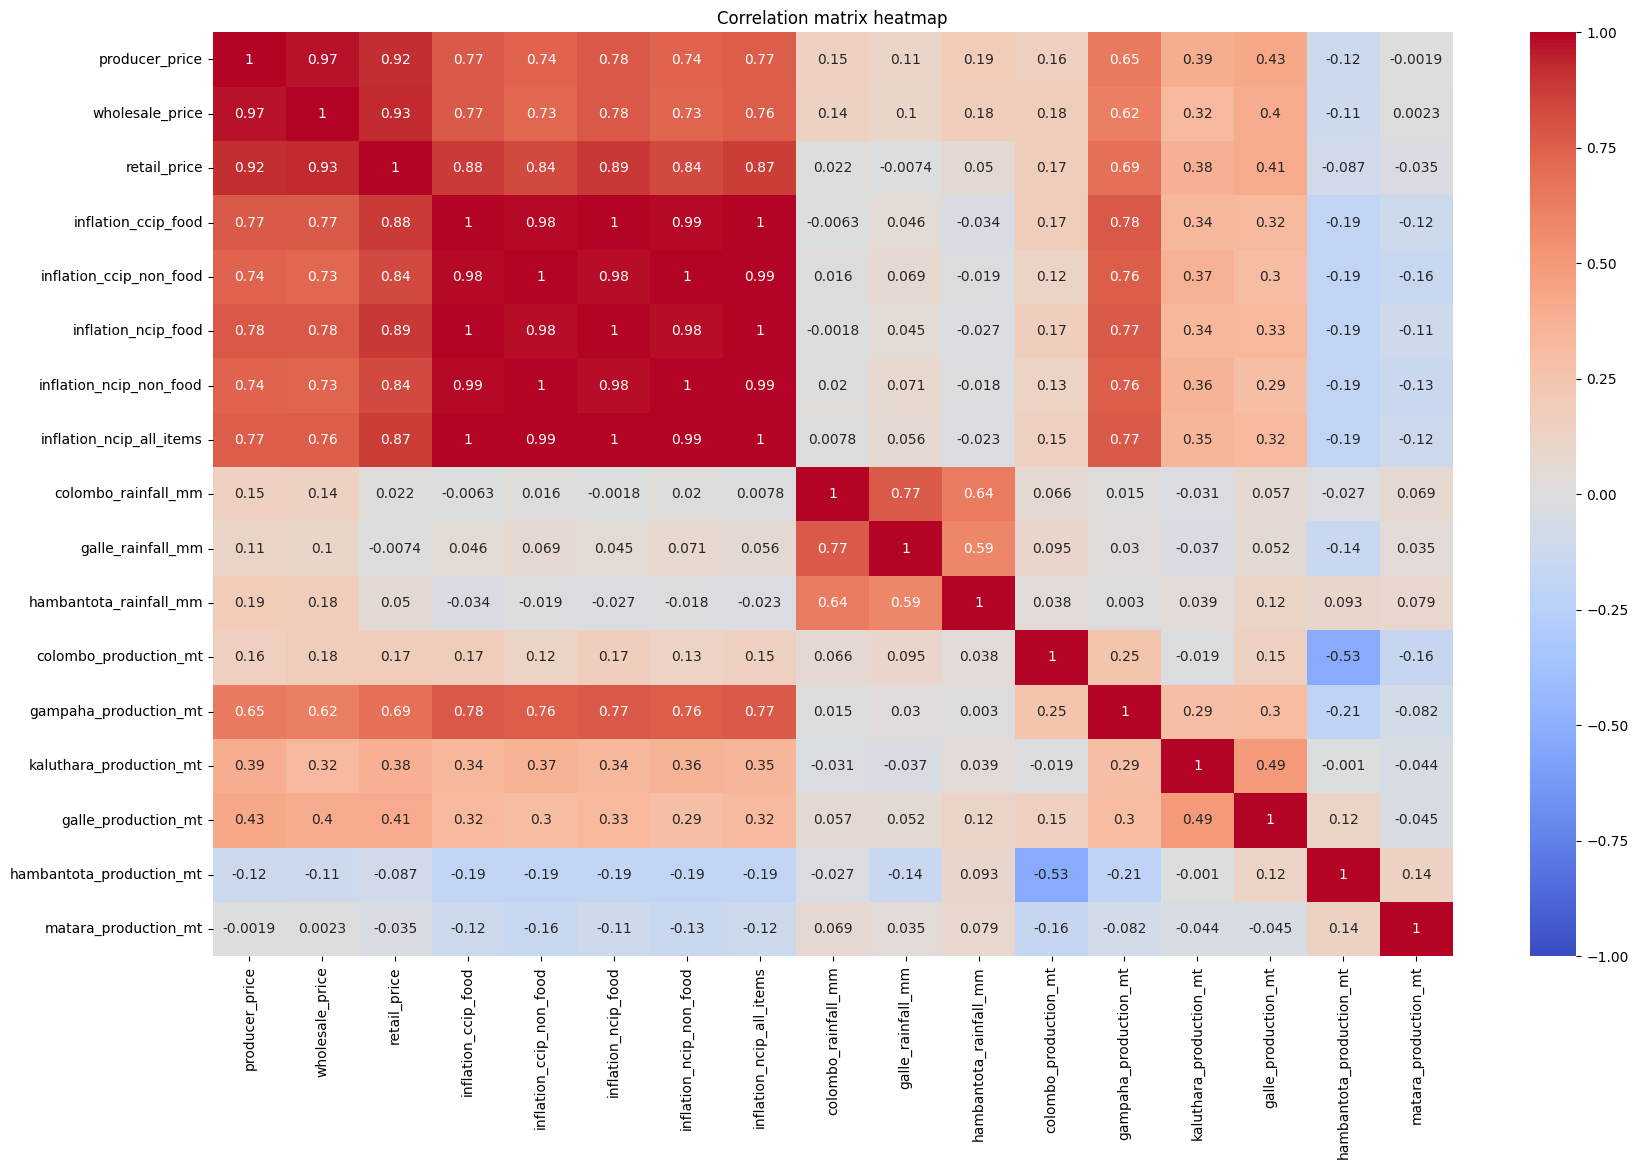

In [74]:
numeric_columns = df.select_dtypes(include=['float64', 'float64'])
correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation matrix heatmap")
plt.show()

As shown in the above correlation heat map the infulence of the production in the gampaha regrion is highly and directly propotinoal to the prices. Hambantota and Matara have a very low correlation matrix with the prices. Further the rainfall affecting the relavent region also shows a very low correlation to the production.